In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_theme(style="whitegrid")

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(nav.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [6]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


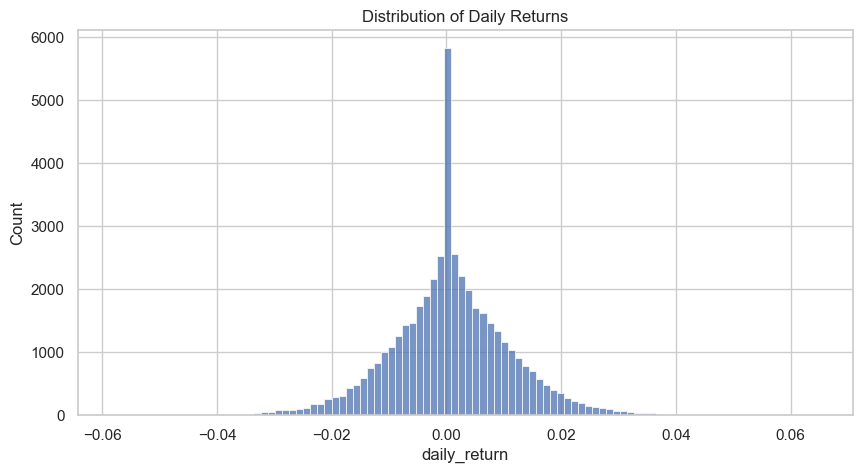

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")

plt.savefig(
    "../reports/daily_return_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [8]:
def calculate_cagr(df, years):

    results = []

    for code in df["amfi_code"].unique():

        temp = df[
            df["amfi_code"] == code
        ].sort_values("date")

        if len(temp) < 252 * years:
            continue

        start_nav = temp.iloc[-252*years]["nav"]
        end_nav = temp.iloc[-1]["nav"]

        cagr = (
            (end_nav / start_nav)
            ** (1/years)
            - 1
        )

        results.append(
            [code, cagr]
        )

    return pd.DataFrame(
        results,
        columns=["amfi_code",
                 f"cagr_{years}yr"]
    )

In [9]:
cagr_1 = calculate_cagr(nav,1)

cagr_3 = calculate_cagr(nav,3)

cagr_5 = calculate_cagr(nav,5)

In [10]:
cagr_table = (
    cagr_1
    .merge(cagr_3,on="amfi_code")
    .merge(cagr_5,on="amfi_code")
)

cagr_table.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr


In [11]:
RF = 0.065

In [12]:
sharpe_list = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    mean_ret = (
        temp["daily_return"]
        .mean()
        * 252
    )

    vol = (
        temp["daily_return"]
        .std()
        * np.sqrt(252)
    )

    sharpe = (
        mean_ret - RF
    ) / vol

    sharpe_list.append(
        [code, sharpe]
    )

In [13]:
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [14]:
sortino_list = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        temp["daily_return"]
        .mean()
        * 252
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_list.append(
        [code, sortino]
    )

In [15]:
sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


Alpha & Beta (vs Nifty 100)

In [16]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

In [17]:
nifty100 = benchmark[
    benchmark["index_name"].str.contains(
        "NIFTY",
        case=False,
        na=False
    )
]

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [18]:
alpha_beta_list = []

for code in nav["amfi_code"].unique():

    fund = nav[
        ["date", "daily_return"]
    ][nav["amfi_code"] == code]

    merged = pd.merge(
        fund,
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_list.append(
        [code, alpha, beta]
    )

In [19]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.035334,0.002548
1,100025,0.043142,-0.002107
2,100033,0.269277,0.020677
3,101206,0.213311,0.009749
4,101207,0.108270,-0.009542


In [20]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

#Maximum Drawdown

In [21]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["running_max"] = (
        temp["nav"]
        .cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp[
        "drawdown"
    ].min()

    drawdown_results.append(
        [code, max_dd]
    )

In [22]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


#Fund Scorecard (0–100)

In [23]:
scorecard = (
    performance[
        [
            "amfi_code",
            "return_3yr_pct",
            "expense_ratio_pct"
        ]
    ]
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
)

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown
0,119551,12.36,1.54,1.208267,0.234519,-0.025441,-0.150124
1,119552,11.30,0.66,0.953279,0.198530,-0.004736,-0.118035
2,119598,23.39,1.43,0.945308,0.299554,0.022641,-0.287060
3,119599,23.14,0.72,-0.057187,0.049746,0.007192,-0.525742
4,119120,6.07,0.77,-0.226575,0.056159,-0.001076,-0.043287


In [24]:
scorecard["return_rank"] = (
    scorecard[
        "return_3yr_pct"
    ].rank(
        ascending=False
    )
)

scorecard["sharpe_rank"] = (
    scorecard[
        "sharpe_ratio"
    ].rank(
        ascending=False
    )
)

scorecard["alpha_rank"] = (
    scorecard[
        "alpha"
    ].rank(
        ascending=False
    )
)

scorecard["expense_rank"] = (
    scorecard[
        "expense_ratio_pct"
    ].rank(
        ascending=True
    )
)

scorecard["dd_rank"] = (
    scorecard[
        "max_drawdown"
    ].rank(
        ascending=True
    )
)

In [25]:
scorecard["fund_score"] = (

      0.30 * scorecard["return_rank"]

    + 0.25 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["alpha_rank"]

    + 0.15 * scorecard["expense_rank"]

    + 0.10 * scorecard["dd_rank"]

)

In [26]:
scorecard["fund_score"] = (

    100 *

    (
        scorecard["fund_score"]
        -
        scorecard["fund_score"].min()
    )

    /

    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"].min()
    )

)

In [27]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
30,101208,5.14,0.79,-0.815567,0.060897,-0.000197,-0.001622,40.0,40.0,33.0,11.0,38.0,100.000000
4,119120,6.07,0.77,-0.226575,0.056159,-0.001076,-0.043287,38.0,37.0,34.0,9.0,36.0,93.750000
9,100025,7.37,0.56,-0.567095,0.043142,-0.002107,-0.043083,36.0,39.0,38.0,2.0,37.0,92.803030
19,118636,5.31,0.55,-0.356630,0.051145,-0.002614,-0.083164,39.0,38.0,35.0,1.0,35.0,91.666667
24,119092,11.84,1.64,0.030785,0.067340,0.014267,-0.144016,31.0,31.0,31.0,39.5,26.0,91.382576
23,120844,6.18,0.60,-0.088747,0.064575,-0.000222,-0.001163,37.0,34.0,32.0,3.0,39.0,85.984848
14,120507,7.68,0.74,0.495723,0.067529,-0.000589,-0.000977,35.0,23.0,30.0,7.0,40.0,74.431818
5,100016,14.84,1.55,-0.201517,0.035334,0.002548,-0.247344,16.0,35.0,39.0,32.0,7.0,72.727273
20,120841,12.25,1.59,0.494273,0.131628,-0.000585,-0.175736,28.0,24.0,25.0,35.0,17.0,70.833333
37,149322,12.82,1.54,0.464037,0.132249,-0.004684,-0.148446,25.0,25.0,24.0,30.5,25.0,68.087121


In [28]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

#Benchmark Comparison Chart

In [29]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5_codes = (
    top5["amfi_code"]
    .tolist()
)

top5_codes

[101208, 119120, 100025, 118636, 119092]

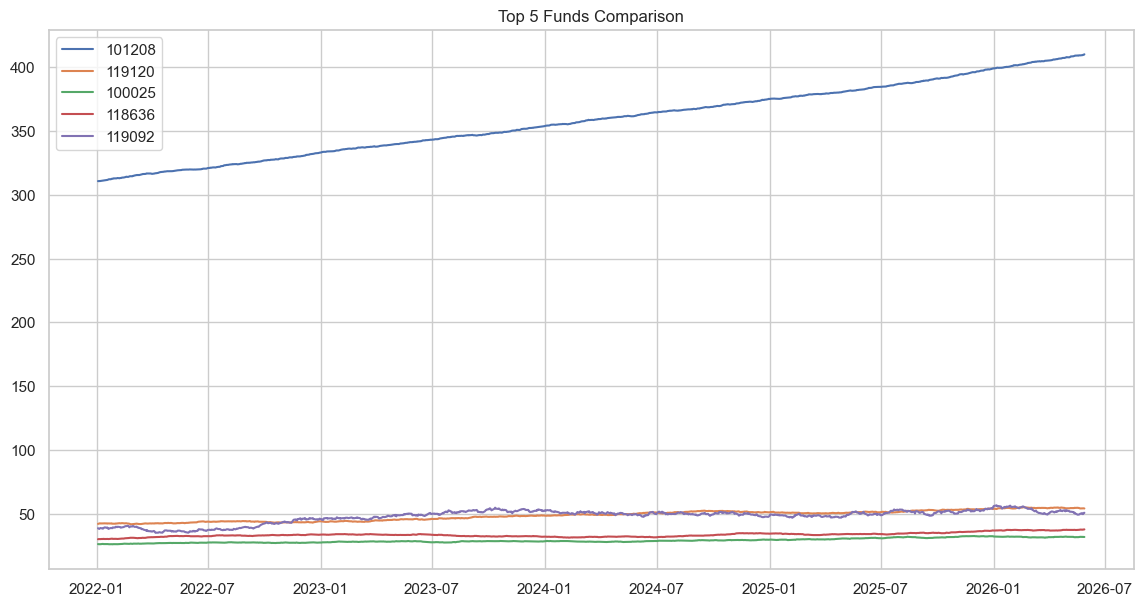

In [30]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = nav[
        nav["amfi_code"]
        == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds Comparison"
)

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()